preprocessing data

In [5]:
import os
from itertools import count
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import glob

folder_path = "MetaDataset"
csv_files = glob.glob(folder_path + "/*.csv")  # Adjust for different file types
file_names = [os.path.basename(file) for file in csv_files]

print(len(file_names))
for i in range (len(file_names)):
    df=pd.read_csv("MetaDataset/"+file_names[i])
    print(file_names[i])
    #imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
    #imputer.fit(df.iloc[:,1:-1])
    #df.iloc[:,1:-1] = imputer.transform(df.iloc[:, 1:-1])
    le = LabelEncoder()
    le.fit(df.iloc[:,-1])
    df.iloc[:,-1] = le.transform(df.iloc[:,-1])
    file_name = 'secondStagepreprocess/'+file_names[i]
    df.to_csv(file_name, index=False)
    


6
complexitymetaDataset.csv
GeneralMetaDatset.csv
infotheoryMetaDataset.csv
landmarkMeta.csv
modelBasedMeta.csv
statisticalMetaDataset.csv


check Balance & save balanced data


Class Distribution of:complexitymetaDataset.csv
 Maxalg
0    88
1    32
Name: count, dtype: int64


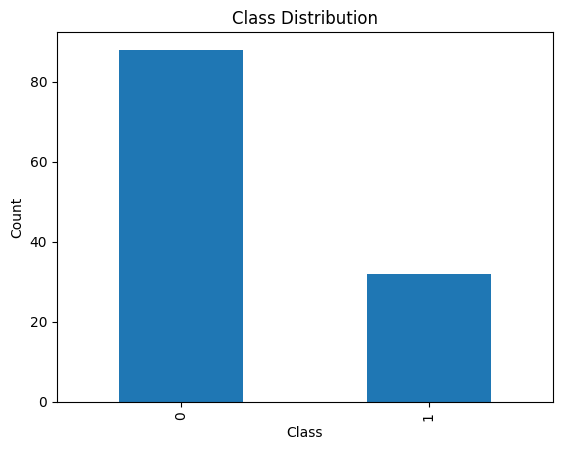

complexitymetaDataset.csvDataset is imbalanced.
Class Distribution of:GeneralMetaDatset.csv
 maxAlgNames
0    90
1    31
Name: count, dtype: int64


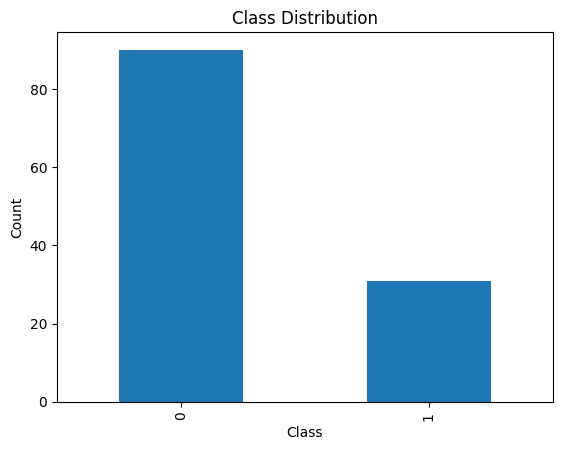

GeneralMetaDatset.csvDataset is imbalanced.
Class Distribution of:infotheoryMetaDataset.csv
 maxAlgNames
0    90
1    31
Name: count, dtype: int64


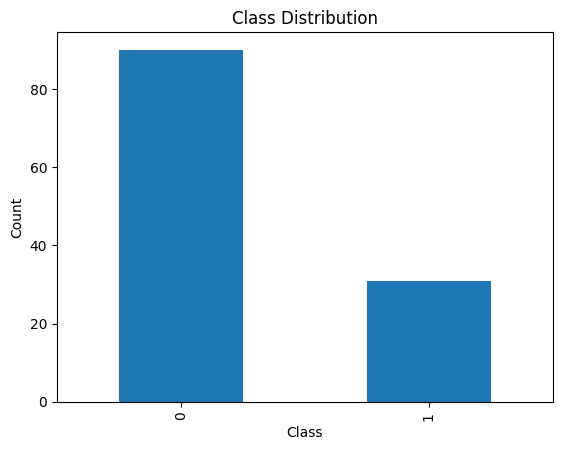

infotheoryMetaDataset.csvDataset is imbalanced.
Class Distribution of:landmarkMeta.csv
 maxAlgNames
0    90
1    31
Name: count, dtype: int64


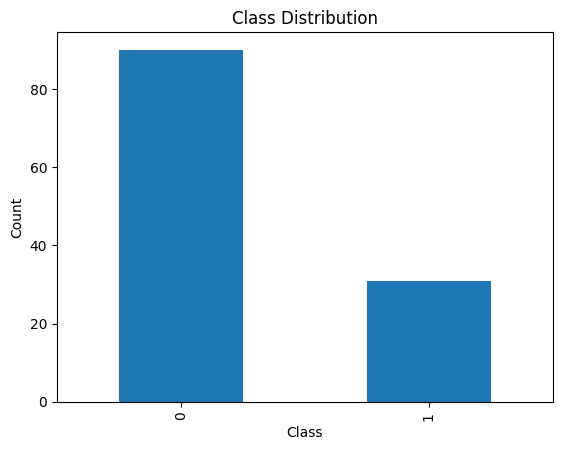

landmarkMeta.csvDataset is imbalanced.
Class Distribution of:modelBasedMeta.csv
 maxAlgNames
0    90
1    31
Name: count, dtype: int64


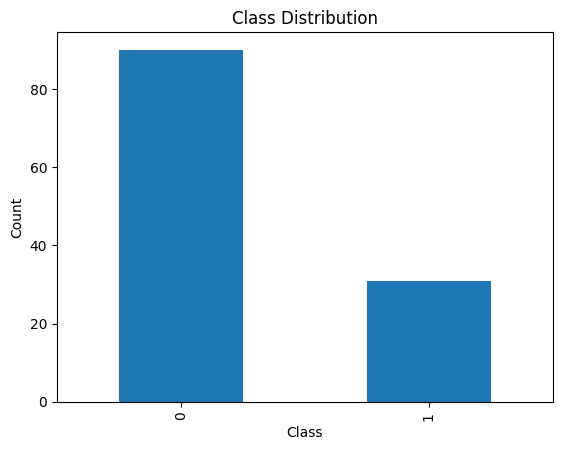

modelBasedMeta.csvDataset is imbalanced.
Class Distribution of:statisticalMetaDataset.csv
 maxAlgNames
0    90
1    31
Name: count, dtype: int64


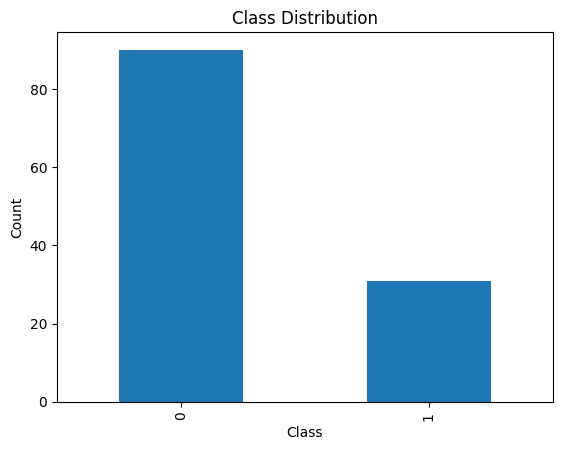

statisticalMetaDataset.csvDataset is imbalanced.
0
6


In [6]:
import glob
imbalnceddata=[]
balnceddata=[]

folder_path = "secondStagepreprocess/"
csv_files = glob.glob(folder_path + "/*.csv")
file_names = [os.path.basename(file) for file in csv_files]
for i in range (len(file_names)):
# Load dataset
    df = pd.read_csv('secondStagepreprocess/'+file_names[i])  # Replace with your dataset

# Check class distribution
    class_counts = df.iloc[:,-1].value_counts()
    print("Class Distribution of:"+file_names[i]+"\n", class_counts)

# Visualize class distribution
    class_counts.plot(kind='bar')
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title("Class Distribution")
    plt.show()

    # Check imbalance
    imbalance_ratio = class_counts.min() / class_counts.max()
    
   
    if imbalance_ratio < 0.5:  # If the minority class is less than 50% of the majority
        print(file_names[i]+"Dataset is imbalanced.")
        apply_ros = True
        imbalnceddata.append(file_names[i])
        
    else:
        print(file_names[i]+"Dataset is balanced.")
        apply_ros = False
        balnceddata.append(file_names[i])
for i in range (len(balnceddata)):
    df = pd.read_csv('secondStagepreprocess/'+balnceddata[i])
    file_name = 'balancedData/'+balnceddata[i]
    df.to_csv(file_name, index=False)
print(len(balnceddata))    
print(len(imbalnceddata))

Apply random oversamplimg on imbalanced data & save output files
 

In [7]:

count=0
for i in range (len(imbalnceddata)):
# Load dataset
    df = pd.read_csv("secondStagepreprocess/"+imbalnceddata[i])
    print(imbalnceddata[i])
    
    if apply_ros:
        # Features and target
        X = df.iloc[:,0:-1]  # Features
        y = df.iloc[:,-1]  # Target variable

    # Apply RandomOverSampler
        from imblearn.over_sampling import RandomOverSampler

        ros = RandomOverSampler(random_state=42)
        X_resampled, y_resampled = ros.fit_resample(X, y)

    # Check new class distribution
        print("After balance:", Counter(y_resampled))
        
    # Convert back to DataFrame
        ros = pd.DataFrame(X_resampled, columns=X.columns)
        ros['target'] = y_resampled
        file_name = 'secondStagepreprocess/balancedsecondstage/'+imbalnceddata[i]
        ros.to_csv(file_name, index=False)
        print("Balanced dataset saved as 'balanced_dataset.csv'.")
        print(" applied successfully.")
        count =count+1
    else:
        print("No need to apply ros. Dataset is already balanced.")
    
        
print(count)

complexitymetaDataset.csv
After balance: Counter({0: 88, 1: 88})
Balanced dataset saved as 'balanced_dataset.csv'.
 applied successfully.
GeneralMetaDatset.csv
After balance: Counter({0: 90, 1: 90})
Balanced dataset saved as 'balanced_dataset.csv'.
 applied successfully.
infotheoryMetaDataset.csv
After balance: Counter({0: 90, 1: 90})
Balanced dataset saved as 'balanced_dataset.csv'.
 applied successfully.
landmarkMeta.csv
After balance: Counter({0: 90, 1: 90})
Balanced dataset saved as 'balanced_dataset.csv'.
 applied successfully.
modelBasedMeta.csv
After balance: Counter({0: 90, 1: 90})
Balanced dataset saved as 'balanced_dataset.csv'.
 applied successfully.
statisticalMetaDataset.csv
After balance: Counter({0: 90, 1: 90})
Balanced dataset saved as 'balanced_dataset.csv'.
 applied successfully.
6


Class Distribution of:secondStagepreprocess/balancedsecondstage\complexitymetaDataset.csv
 target
0    88
1    88
Name: count, dtype: int64


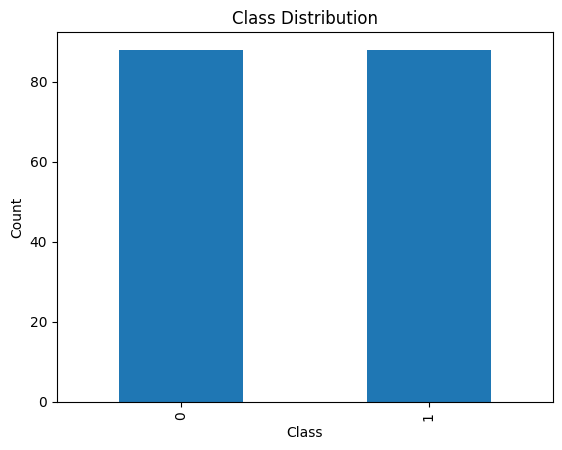

Dataset is balanced.
Class Distribution of:secondStagepreprocess/balancedsecondstage\GeneralMetaDatset.csv
 target
0    90
1    90
Name: count, dtype: int64


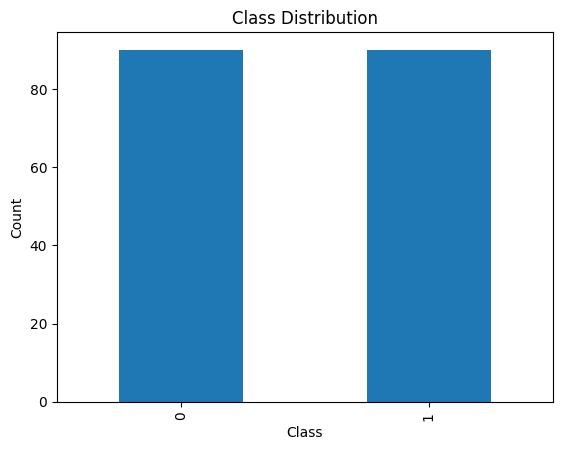

Dataset is balanced.
Class Distribution of:secondStagepreprocess/balancedsecondstage\infotheoryMetaDataset.csv
 target
0    90
1    90
Name: count, dtype: int64


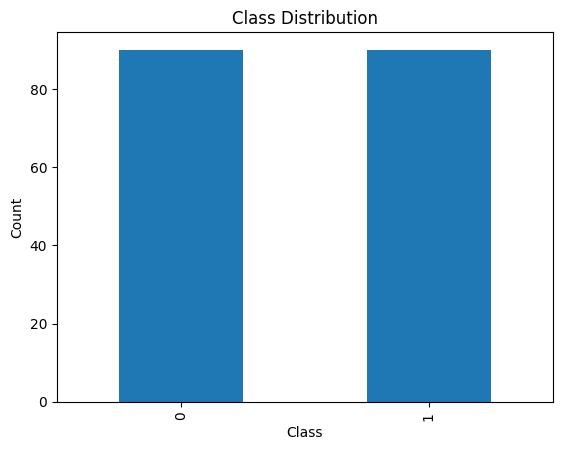

Dataset is balanced.
Class Distribution of:secondStagepreprocess/balancedsecondstage\landmarkMeta.csv
 target
0    90
1    90
Name: count, dtype: int64


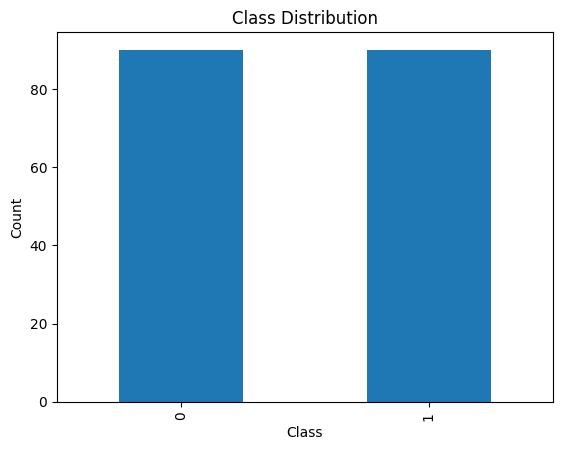

Dataset is balanced.
Class Distribution of:secondStagepreprocess/balancedsecondstage\modelBasedMeta.csv
 target
0    90
1    90
Name: count, dtype: int64


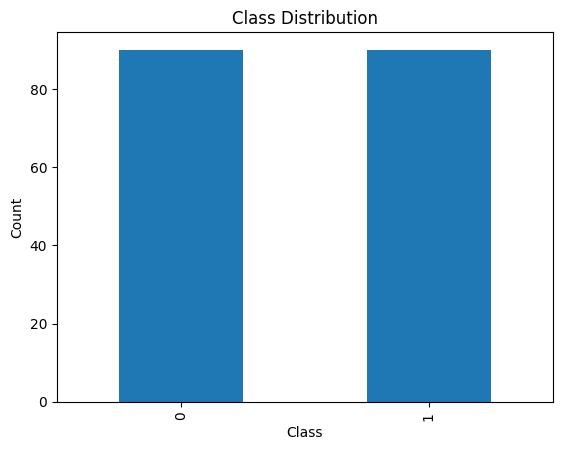

Dataset is balanced.
Class Distribution of:secondStagepreprocess/balancedsecondstage\statisticalMetaDataset.csv
 target
0    90
1    90
Name: count, dtype: int64


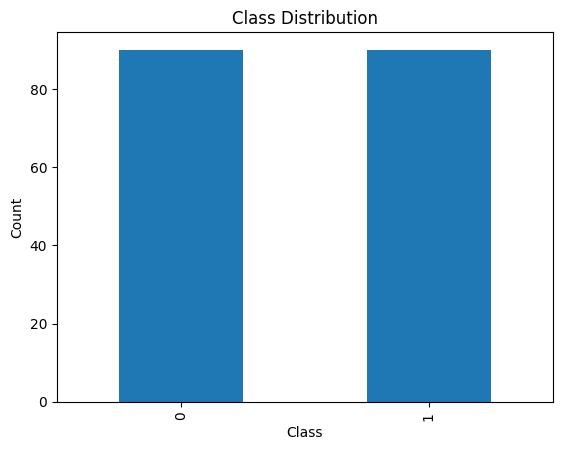

Dataset is balanced.
0


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import glob
imbalnceddata=[]
folder_path = "secondStagepreprocess/balancedsecondstage"
csv_files = glob.glob(folder_path + "/*.csv")  # Adjust for different file types

for i in range (len(csv_files)):
# Load dataset
    df = pd.read_csv(csv_files[i])  # Replace with your dataset

# Check class distribution
    class_counts = df.iloc[:,-1].value_counts()
    print("Class Distribution of:"+csv_files[i]+"\n", class_counts)

# Visualize class distribution
    class_counts.plot(kind='bar')
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title("Class Distribution")
    plt.show()
    
    # Check imbalance
    imbalance_ratio = class_counts.min() / class_counts.max()
    if imbalance_ratio < 0.5:  # If the minority class is less than 50% of the majority
        print("Dataset is imbalanced.")
        apply_smote = True
        imbalnceddata.append(csv_files[i])
        
    else:
        print("Dataset is balanced.")
        apply_smote = False
print(len(imbalnceddata))